# Lesson 2.3 - Probability & Statistics (Titanic-Style Analysis)

## Objectives
- Compute marginal, joint, and conditional probabilities.
- Perform descriptive statistics and distribution checks.
- Connect subgroup probabilities to business risk decisions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Section A - Load Titanic Data (with fallback)

We try loading seaborn Titanic first. If unavailable, we generate a Titanic-like synthetic dataset so the notebook remains runnable offline.

In [2]:
def load_titanic_like(n: int = 800) -> pd.DataFrame:
    try:
        import seaborn as sns

        df = sns.load_dataset("titanic")
        cols = ["survived", "sex", "pclass", "age", "fare"]
        return df[cols].copy()
    except Exception:
        sex = np.random.choice(["male", "female"], size=n, p=[0.62, 0.38])
        pclass = np.random.choice([1, 2, 3], size=n, p=[0.24, 0.23, 0.53])
        age = np.clip(np.random.normal(30, 14, size=n), 1, 80)
        fare = np.clip(np.random.lognormal(mean=3.1, sigma=0.7, size=n), 5, 300)

        base = 0.35 + 0.25 * (sex == "female") + 0.12 * (pclass == 1) - 0.10 * (pclass == 3)
        base -= 0.06 * (age > 55)
        prob = np.clip(base, 0.03, 0.97)
        survived = np.random.binomial(1, prob)

        df = pd.DataFrame(
            {
                "survived": survived,
                "sex": sex,
                "pclass": pclass,
                "age": age,
                "fare": fare,
            }
        )
        age_missing_idx = np.random.choice(df.index, size=int(0.08 * n), replace=False)
        fare_missing_idx = np.random.choice(df.index, size=int(0.02 * n), replace=False)
        df.loc[age_missing_idx, "age"] = np.nan
        df.loc[fare_missing_idx, "fare"] = np.nan
        return df


titanic_df = load_titanic_like()
print("shape:", titanic_df.shape)
display(titanic_df.head())

shape: (891, 5)


,survived,sex,pclass,age,fare
0,0,male,3,22.0,7.2500
1,1,female,1,38.0,71.2833
2,1,female,3,26.0,7.9250
3,1,female,1,35.0,53.1000
4,0,male,3,35.0,8.0500


## Section B - Descriptive Statistics

In [3]:
print("P(survived):", round(float(titanic_df["survived"].mean()), 4))
display(titanic_df[["age", "fare", "survived"]].describe(include="all"))
print("missing ratios:\n", titanic_df.isna().mean().sort_values(ascending=False))


P(survived): 0.3838


,age,fare,survived
count,714.000000,891.000000,891.000000
mean,29.699118,32.204208,0.383838
std,14.526497,49.693429,0.486592
min,0.420000,0.000000,0.000000
25%,20.125000,7.910400,0.000000
50%,28.000000,14.454200,0.000000
75%,38.000000,31.000000,1.000000
max,80.000000,512.329200,1.000000


missing ratios:
 age         0.198653
survived    0.000000
sex         0.000000
pclass      0.000000
fare        0.000000
dtype: float64


## Section C - Conditional Probability Functions

In [4]:
def conditional_survival(df: pd.DataFrame, column: str, value) -> float:
    sub = df[df[column] == value]
    if len(sub) == 0:
        raise ValueError(f"No rows for {column}={value}")
    return float(sub["survived"].mean())


print("P(survived | female):", round(conditional_survival(titanic_df, "sex", "female"), 4))
print("P(survived | male):", round(conditional_survival(titanic_df, "sex", "male"), 4))
for cls in sorted(titanic_df["pclass"].dropna().unique()):
    print(f"P(survived | pclass={cls}):", round(conditional_survival(titanic_df, "pclass", cls), 4))

P(survived | female): 0.742
P(survived | male): 0.1889
P(survived | pclass=1): 0.6296
P(survived | pclass=2): 0.4728
P(survived | pclass=3): 0.2424


## Section D - Distribution and Quantile View

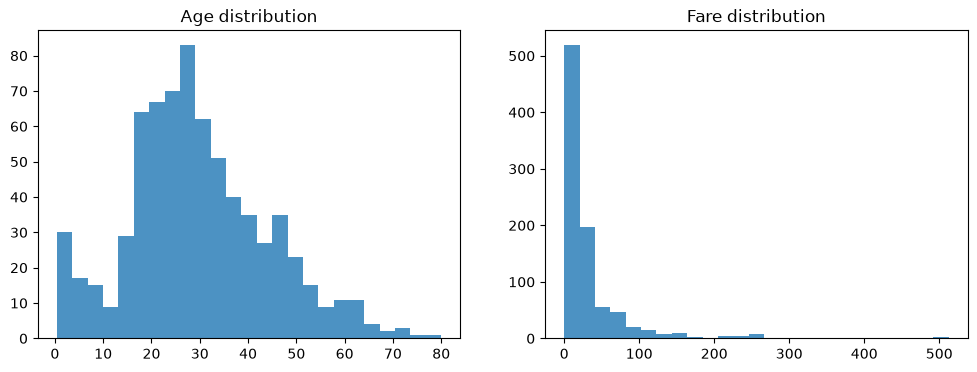

Age quantiles:
 0.10    14.000
0.25    20.125
0.50    28.000
0.75    38.000
0.90    50.000
Name: age, dtype: float64
Fare quantiles:
 0.10     7.5500
0.25     7.9104
0.50    14.4542
0.75    31.0000
0.90    77.9583
Name: fare, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(titanic_df["age"].dropna(), bins=25, alpha=0.8)
axes[0].set_title("Age distribution")
axes[1].hist(titanic_df["fare"].dropna(), bins=25, alpha=0.8)
axes[1].set_title("Fare distribution")
plt.show()

print("Age quantiles:\n", titanic_df["age"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))
print("Fare quantiles:\n", titanic_df["fare"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]))


## Section E - Simple Risk Segmentation Example

In [6]:
def toy_risk(row: pd.Series) -> float:
    score = 0.50
    score += 0.20 if row["sex"] == "male" else -0.10
    score += 0.15 if row["pclass"] == 3 else (-0.08 if row["pclass"] == 1 else 0.0)
    if pd.notna(row["age"]) and row["age"] > 55:
        score += 0.10
    return float(np.clip(score, 0.0, 1.0))


risk_df = titanic_df.copy()
risk_df["toy_risk"] = risk_df.apply(toy_risk, axis=1)
bins = pd.cut(risk_df["toy_risk"], bins=[0, 0.4, 0.6, 1.0], include_lowest=True)
print(risk_df.groupby(bins)["survived"].mean())

toy_risk
(-0.001, 0.4]    0.950617
(0.4, 0.6]       0.516556
(0.6, 1.0]       0.190311
Name: survived, dtype: float64


## Business Case Studies & Exceptions
- Subgroup conditional rates support better triage than global averages.
- Tail quantiles (p90/p95) matter for planning beyond mean values.
- Exception: very small subgroups require smoothing or broader grouping.

## Interview Questions & Answers
1. What is conditional probability? Probability of A within subset where B holds.
2. Why avoid causal claims from this notebook alone? Observational associations can be confounded.